# Exploratory Data Analysis (EDA)
Di sini kita akan mengeksplorasi dataset, baik gambar mentahnya maupun fitur-fitur HSI yang telah diekstraksi.

In [1]:
import os
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

## 1. Distribusi Kelas Kematangan Buah
Mari kita lihat seberapa seimbang data yang kita miliki di data *Train*.

In [2]:
train_csv_path = os.path.join(src_path.replace('src', 'data'), 'processed', 'train_features.csv')
if os.path.exists(train_csv_path):
    df_train = pd.read_csv(train_csv_path)
    
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df_train, x='label', order=['mentah', 'matang', 'terlalu matang'], palette='viridis')
    plt.title('Distribusi Kelas pada Data Train')
    plt.xlabel('Tingkat Kematangan')
    plt.ylabel('Jumlah Gambar')
    plt.show()
else:
    print("File train_features.csv belum dibuat. Harap jalankan 02_Preprocessing_and_Extraction.ipynb terlebih dahulu.")

NameError: name 'src_path' is not defined

## 2. Visualisasi Fitur HSI (Hue, Saturation, Intensity)
Kita akan menggunakan *Boxplot* untuk melihat apakah ada perbedaan nilai Hue (Corak) yang signifikan antara buah yang mentah, matang, dan terlalu matang.

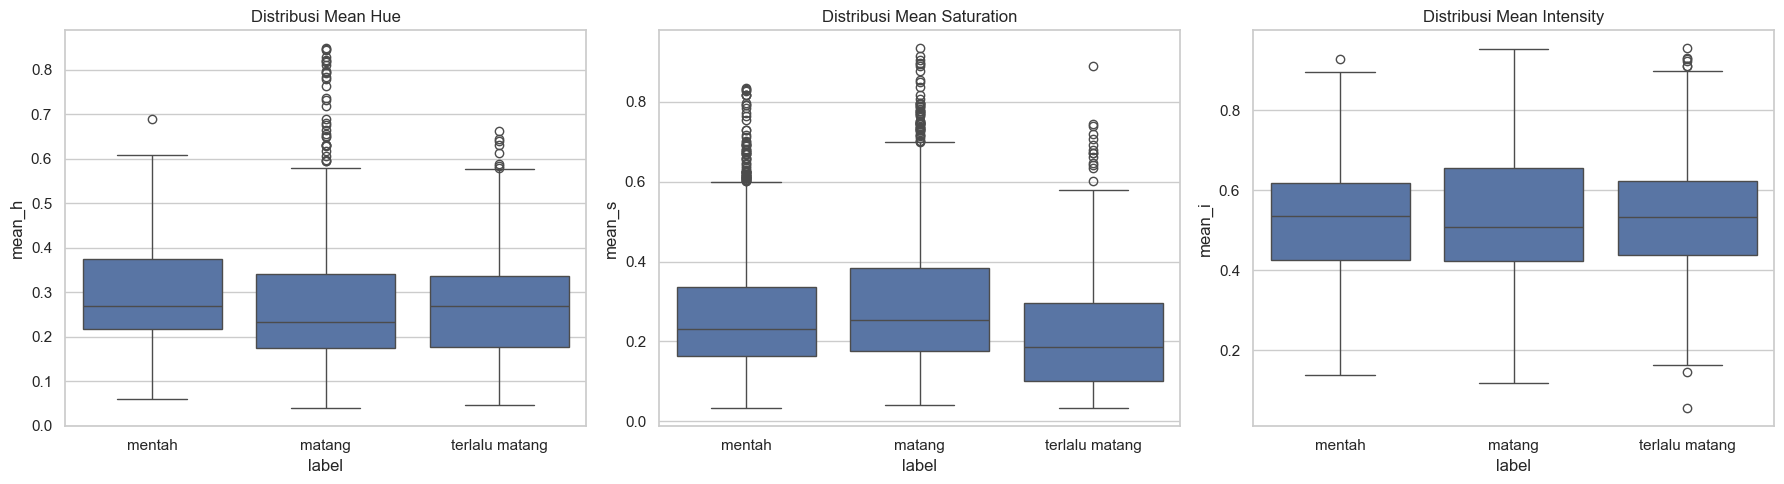

In [ ]:
if os.path.exists(train_csv_path):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    sns.boxplot(ax=axes[0], data=df_train, x='label', y='mean_h', order=['mentah', 'matang', 'terlalu matang'])
    axes[0].set_title('Distribusi Mean Hue')
    
    sns.boxplot(ax=axes[1], data=df_train, x='label', y='mean_s', order=['mentah', 'matang', 'terlalu matang'])
    axes[1].set_title('Distribusi Mean Saturation')
    
    sns.boxplot(ax=axes[2], data=df_train, x='label', y='mean_i', order=['mentah', 'matang', 'terlalu matang'])
    axes[2].set_title('Distribusi Mean Intensity')
    
    plt.tight_layout()
    plt.show()

## 3. Sampel Gambar Mentah vs Gambar Preprocessing
Mari kita lihat satu contoh gambar sebelum dan sesudah diberikan Gaussian Blur (dari `image_utils.py`).

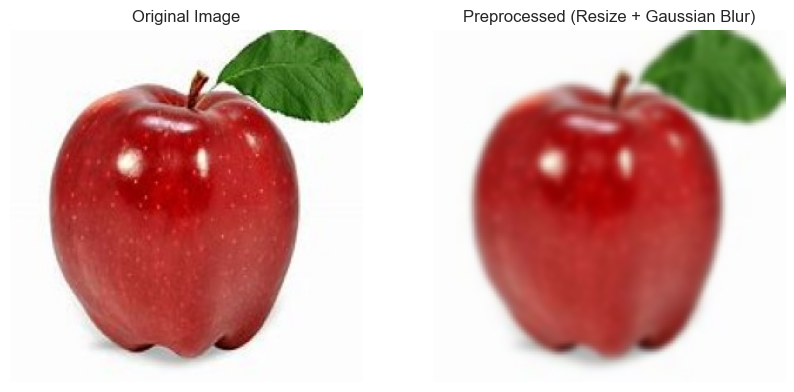

In [ ]:
import os
import sys

# Dapatkan absolute path ke folder src secara dinamis
current_dir = os.path.abspath('')
if 'notebooks' in current_dir:
    src_path = os.path.abspath(os.path.join('..', 'src'))
else:
    src_path = os.path.abspath('src')
    
if src_path not in sys.path:
    sys.path.append(src_path)

from image_utils import load_and_preprocess_image

sample_img_path = os.path.join('..', 'data', 'raw', 'Train', 'Ripe')
if os.path.exists(sample_img_path):
    import glob
    files = glob.glob(os.path.join(sample_img_path, '*.jpg'))
    if len(files) > 0:
        img_raw = cv2.imread(files[0])
        img_raw_rgb = cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB) # BGR ke RGB untuk Matplotlib
        
        img_prep = load_and_preprocess_image(files[0])
        img_prep_rgb = cv2.cvtColor(img_prep, cv2.COLOR_BGR2RGB)
        
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        axes[0].imshow(img_raw_rgb)
        axes[0].set_title('Original Image')
        axes[0].axis('off')
        
        axes[1].imshow(img_prep_rgb)
        axes[1].set_title('Preprocessed (Resize + Gaussian Blur)')
        axes[1].axis('off')
        plt.show()